In [1]:
%matplotlib inline
import numpy as np
import torch
import torchvision
from matplotlib import pyplot as plt
from torch import nn, optim
from torch.utils.data import DataLoader
from ipywidgets import interactive

interactive(children=(FloatSlider(value=5.0, description='x', max=10.0), Output()), _dom_classes=('widget-inte…

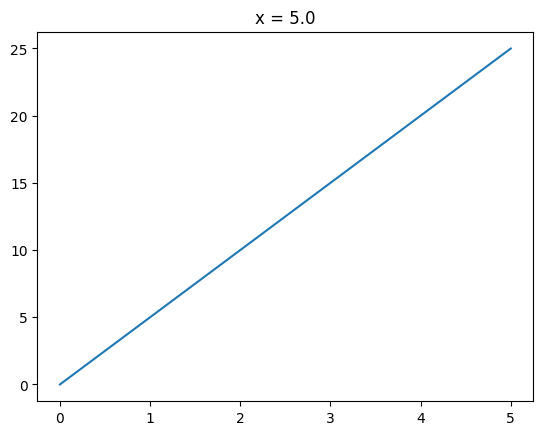

In [2]:
%matplotlib inline
from ipywidgets import interactive
import matplotlib.pyplot as plt
from IPython.display import display

def test_plot(x):
    plt.clf()
    plt.plot([0, x], [0, x**2])
    plt.title(f'x = {x}')

slider = interactive(test_plot, x=(0, 10, 0.1))
display(slider)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

trainset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
testset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [3]:
class AutoEncoder(nn.Module):
    def __init__(self, img_shape, inp_dim, hidden_dim):
        super(AutoEncoder, self).__init__()
        self.img_shape = img_shape
        self.encoder = nn.Sequential(nn.Linear(inp_dim, 256),
                                     nn.ReLU(),
                                     nn.Linear(256, 128),
                                     nn.ReLU(),
                                     nn.Linear(128, hidden_dim)
                                     )
        self.decoder = nn.Sequential(nn.Linear(hidden_dim, 128),
                                     nn.ReLU(),
                                     nn.Linear(128, 256),
                                     nn.ReLU(),
                                     nn.Linear(256, inp_dim)
                                     )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(x.size(0),*self.img_shape)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self,x):
        return self.decoder(x).view(*self.img_shape)

In [4]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, img_shape, inp_dim, hidden_dim):
        super().__init__()
        self.encoder=nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # -> 16x28x28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> 16x14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # -> 32x14x14
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.decoder=nn.Sequential(
            nn.ConvTranspose2d(32,16,kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    def encode(self, x):
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x)

In [5]:
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
BATCH_SIZE = 128

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=32,
    pin_memory=True,
    persistent_workers=True
)
testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=32,
    pin_memory=True,
    persistent_workers=True
)

In [6]:
def train(model, trainloader, index):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    arr_loss=[]

    for epoch in range(NUM_EPOCHS):
        train_loss = 0
        counter = 0
        for images, _ in trainloader:
            images = images.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            counter+=images.size(0)
        arr_loss.append(train_loss)
        print(f"epoch {epoch}: loss {train_loss/counter}")
    torch.save(model.state_dict(), f"model{index}.pth")
    return arr_loss

In [7]:
def count_matches(start, end, threshold=0.05):

    mse_per_image = torch.mean((start - end) ** 2, dim=(1, 2, 3))

    matches = (mse_per_image <= threshold)
    return matches.sum().item()

In [8]:
def inter_plot(model):
    def plot(z1, z2, z3, z4):
        plt.figure(2)
        z = torch.Tensor([[z1, z2, z3, z4]]).to(device)
        decoded = model.decoder(z)
        img = decoded.reshape(28, 28).to('cpu').detach().numpy()
        plt.imshow(img, cmap='gray')
        # plt.show()

    interactive_plot = interactive(plot, z1=(0., 1., 0.01), z2=(0., 1., 0.01), z3=(0., 1., 0.01), z4=(0., 1., 0.01))
    display(interactive_plot)
    # output = interactive_plot.children[-1]
    # output.layout.height = '350px'

In [9]:
def val(vers, index):

    if vers == 'conv':
        model = ConvAutoEncoder([28,28],28*28,28).to(device)
    else:
        model = AutoEncoder([1,28,28],28*28,28).to(device)

    model.load_state_dict(torch.load(f"model{index}.pth", map_location=device))
    with torch.no_grad():
        ans = 0
        vsego = 0
        model.eval()
        for images, _ in testloader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            ans+=count_matches(images, outputs)
            vsego+=images.size(0)

        print(f"точность {ans/vsego}")
        inter_plot(model)

In [10]:
model = AutoEncoder([1,28,28],28*28,28).to(device)
fc_loss = train(model, trainloader,1)
model = ConvAutoEncoder([28,28],28*28,28).to(device)
conv_loss = train(model, trainloader,2)

val('lin',1)
val('conv',2)

epoch 0: loss 0.034735685631632804
epoch 1: loss 0.019721664731701217
epoch 2: loss 0.01692281572322051
epoch 3: loss 0.015456732485195001
epoch 4: loss 0.01444847678989172
epoch 5: loss 0.013778663224975268
epoch 6: loss 0.013277458381652832
epoch 7: loss 0.01287572558671236
epoch 8: loss 0.012551516809066137
epoch 9: loss 0.012292520693937938
epoch 10: loss 0.012038476221263408
epoch 11: loss 0.011854986350238322
epoch 12: loss 0.011698774035274983
epoch 13: loss 0.011552576047678788
epoch 14: loss 0.011446530263622601
epoch 15: loss 0.011330884415407975
epoch 16: loss 0.011255469192564488
epoch 17: loss 0.011155073244373004
epoch 18: loss 0.011097176393866539
epoch 19: loss 0.011033388885855675
epoch 0: loss 0.026514609185854594
epoch 1: loss 0.0084278811643521
epoch 2: loss 0.006754913810888926
epoch 3: loss 0.006109031193206708
epoch 4: loss 0.005716259017835061
epoch 5: loss 0.005440381598969301
epoch 6: loss 0.0052287443118790786
epoch 7: loss 0.00506210132042567
epoch 8: loss 0

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

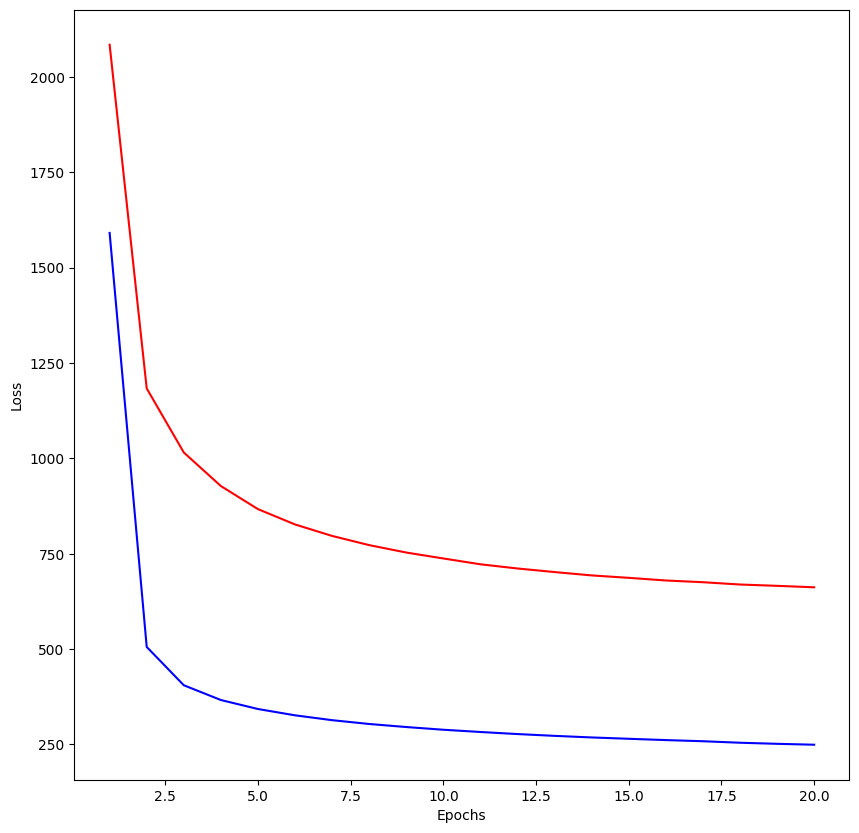

In [11]:
plt.figure(figsize=(10,10))
plt.plot(list(range(1,21)),fc_loss,label='fc_loss',color='red')
plt.plot(list(range(1,21)),conv_loss,label='conv_loss',color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.savefig('graph.png')